# 日経平均株価 15分足

In [1]:
import sys

path_up = ".."
if not path_up in sys.path:
    sys.path.append(path_up)

In [2]:
import datetime

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import mplfinance as mpf
import numpy as np
import pandas as pd
import yfinance as yf

from funcs.commons import get_name_15min_chart, get_name_15min_chart_usd

In [3]:
code = "N225"
symbol = f"^{code}"
yticker = yf.Ticker(symbol)
df = yticker.history(period="1d", interval="15m")
df

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Datetime,,,,,,,
2026-05-21 09:00:00+09:00,60374.839844,61406.410156,60282.351562,61319.828125,0,0.0,0.0
2026-05-21 09:15:00+09:00,61314.199219,61574.019531,61314.199219,61519.640625,0,0.0,0.0
2026-05-21 09:30:00+09:00,61549.789062,61730.070312,61520.109375,61605.871094,0,0.0,0.0
2026-05-21 09:45:00+09:00,61590.460938,61765.781250,61566.738281,61663.398438,0,0.0,0.0
2026-05-21 10:00:00+09:00,61660.500000,61861.539062,61660.500000,61853.980469,0,0.0,0.0
2026-05-21 10:15:00+09:00,61856.671875,61962.589844,61813.781250,61840.000000,0,0.0,0.0
2026-05-21 10:30:00+09:00,61846.808594,61895.960938,61768.960938,61774.628906,0,0.0,0.0
2026-05-21 10:45:00+09:00,61766.988281,61899.601562,61745.539062,61872.210938,0,0.0,0.0
2026-05-21 11:00:00+09:00,61872.390625,61959.000000,61861.718750,61937.058594,0,0.0,0.0


In [4]:
dt_start = df.index[0]
dt_end = pd.to_datetime(
    f"{dt_start.year:04d}-{dt_start.month:02d}-{dt_start.day:02d} 15:30:00+09:00"
).tz_convert("Asia/Tokyo")
dt_start, dt_end

(Timestamp('2026-05-21 09:00:00+0900', tz='Asia/Tokyo'),
 Timestamp('2026-05-21 15:30:00+0900', tz='Asia/Tokyo'))

In [5]:
# 過去一週間のデータを取得
td = datetime.timedelta(days=7)
dt_first = df.index[0]
dt_prev = dt_first - td
df_last = yticker.history(interval="1d", start=str(dt_prev.date()))
print(df_last["Close"])
n = len(df_last)
lastclose = df_last[n - 2 : n - 1]["Close"].iloc[0]
# lastclose = 56308.42  # 4/8 終値
# 確認のため出力
df_last[n - 2 : n - 1]["Close"]

Date
2026-05-14 00:00:00+09:00    62654.050781
2026-05-15 00:00:00+09:00    61409.289062
2026-05-18 00:00:00+09:00    60815.949219
2026-05-19 00:00:00+09:00    60550.589844
2026-05-20 00:00:00+09:00    59804.410156
2026-05-21 00:00:00+09:00    61684.140625
Name: Close, dtype: float64


Date
2026-05-20 00:00:00+09:00    59804.410156
Name: Close, dtype: float64

In [6]:
delta_open = df.head(1)["Open"].iloc[0] - lastclose
print(f"{delta_open:+.2f}")

+570.43


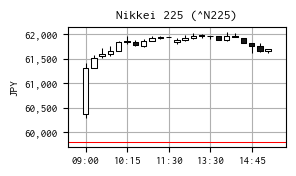

In [7]:
FONT_PATH = "../fonts/RictyDiminished-Regular.ttf"
fm.fontManager.addfont(FONT_PATH)

# FontPropertiesオブジェクト生成（名前の取得のため）
font_prop = fm.FontProperties(fname=FONT_PATH)
font_prop.get_name()

plt.rcParams["font.family"] = font_prop.get_name()
plt.rcParams["font.size"] = 8

fig, ax = plt.subplots(figsize=(3, 1.8))

ax.axhline(y=lastclose, color="red", linewidth=0.75)
mpf.plot(
    df,
    type="candle",
    style="default",
    datetime_format="%H:%M",
    xrotation=0,
    update_width_config=dict(candle_linewidth=0.75),
    ax=ax,
)
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))
ax.set_ylabel("JPY")
ax.grid()

if "shortName" in yticker.info:
    ax.set_title(f"{yticker.info['shortName']} ({symbol})")
elif "longName" in yticker.info:
    ax.set_title(f"{yticker.info['longName']} ({symbol})")
else:
    ax.set_title(f"{symbol}")

plt.tight_layout()
plt.savefig(get_name_15min_chart(code, dt_first))
plt.show()

In [8]:
code2 = "USDJPY=X"
symbol2 = code2
ticker2 = yf.Ticker(symbol2)

In [9]:
# 15分足で過去 2 日分のデータを取得
df_exchange = ticker2.history(period="2d", interval="15m")
df_exchange.index = df_exchange.index.tz_convert("Asia/Tokyo")
df_exchange

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Datetime,,,,,,,
2026-05-20 08:00:00+09:00,159.056000,159.072006,159.016006,159.029007,0,0.0,0.0
2026-05-20 08:15:00+09:00,159.029007,159.050003,159.011993,159.028000,0,0.0,0.0
2026-05-20 08:30:00+09:00,159.022995,159.033997,158.979996,158.998001,0,0.0,0.0
2026-05-20 08:45:00+09:00,158.994003,159.057999,158.994003,159.042999,0,0.0,0.0
2026-05-20 09:00:00+09:00,159.035004,159.102997,159.035004,159.078995,0,0.0,0.0
...,...,...,...,...,...,...,...
2026-05-21 14:45:00+09:00,159.005997,159.035004,158.983002,159.009003,0,0.0,0.0
2026-05-21 15:00:00+09:00,159.009995,159.029999,158.983994,159.005005,0,0.0,0.0
2026-05-21 15:15:00+09:00,159.005005,159.057007,158.985992,159.029999,0,0.0,0.0


In [10]:
ser_rate = df_exchange.loc[df.index, "Close"]
ser_rate
df2 = pd.DataFrame()
df2["Open"] = df["Open"] / ser_rate
df2["High"] = df["High"] / ser_rate
df2["Low"] = df["Low"] / ser_rate
df2["Close"] = df["Close"] / ser_rate
df2

,Open,High,Low,Close
Datetime,,,,
2026-05-21 09:00:00+09:00,379.933428,386.425007,379.351408,385.880154
2026-05-21 09:15:00+09:00,385.924850,387.560215,385.924850,387.217943
2026-05-21 09:30:00+09:00,387.424783,388.559562,387.237964,387.777791
2026-05-21 09:45:00+09:00,387.710098,388.813734,387.560764,388.169237
2026-05-21 10:00:00+09:00,388.192530,389.458200,388.192530,389.410614
2026-05-21 10:15:00+09:00,389.415288,390.082089,389.145272,389.310331
2026-05-21 10:30:00+09:00,389.318900,389.628308,388.828857,388.864537
2026-05-21 10:45:00+09:00,388.750347,389.584991,388.615350,389.412600
2026-05-21 11:00:00+09:00,389.413731,389.958835,389.346564,389.820739


In [11]:
dt = df_exchange.head(1).index[0]
dt_last_close = pd.to_datetime(f"{str(dt.date())} 15:15:00+09:00")
print(dt_last_close)
last_close_usd = df_exchange.loc[dt_last_close, "Close"]
last_close_usd

2026-05-20 15:15:00+09:00


np.float64(158.88600158691406)

前日終値（ドル換算） 376.39823243670526


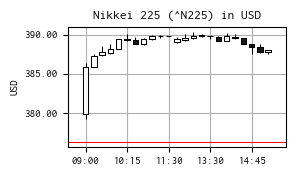

In [12]:
FONT_PATH = "../fonts/RictyDiminished-Regular.ttf"
fm.fontManager.addfont(FONT_PATH)

# FontPropertiesオブジェクト生成（名前の取得のため）
font_prop = fm.FontProperties(fname=FONT_PATH)
font_prop.get_name()

plt.rcParams["font.family"] = font_prop.get_name()
plt.rcParams["font.size"] = 8

fig, ax = plt.subplots(figsize=(3, 1.8))

ax.axhline(y=lastclose / last_close_usd, color="red", linewidth=0.75)
print("前日終値（ドル換算）", lastclose / last_close_usd)
mpf.plot(
    df2,
    type="candle",
    style="default",
    datetime_format="%H:%M",
    xrotation=0,
    update_width_config=dict(candle_linewidth=0.75),
    ax=ax,
)
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.2f}"))
ax.set_ylabel("USD")
ax.grid()

if "shortName" in yticker.info:
    ax.set_title(f"{yticker.info['shortName']} ({symbol}) in USD")
elif "longName" in yticker.info:
    ax.set_title(f"{yticker.info['longName']} ({symbol}) in USD")
else:
    ax.set_title(f"{symbol}")

plt.tight_layout()
plt.savefig(get_name_15min_chart_usd(code, dt_first))
plt.show()